<a href="https://colab.research.google.com/github/ibrahimbugrasan/HasarliAracTespiti-2/blob/main/ConvNext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/convnext/feature_extraction_convnext.py:28: FutureWarning: The class ConvNextFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ConvNextImageProcessor instead.
  warnings.warn(
Some weights of ConvNextForImageClassification were not initialized from the model checkpoint at facebook/convnext-base-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([4, 1024]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/10]
Accuracy: 0.9725, Recall: 0.9725, Precision: 0.9726, F1-Score: 0.9725, AUC: 0.9817
Training Loss: 0.4368, Validation Loss: 0.0922


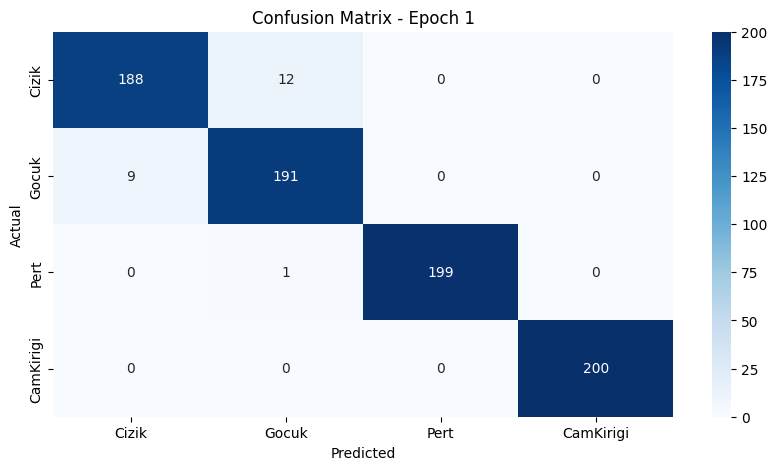

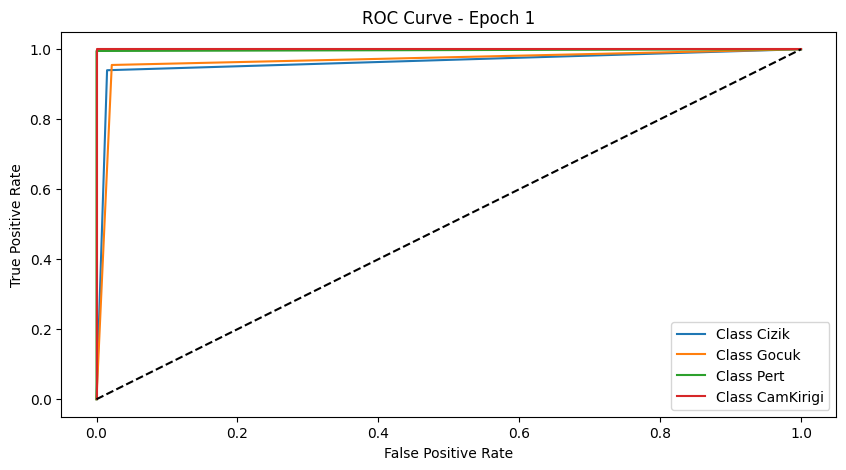

Epoch [2/10]
Accuracy: 0.9938, Recall: 0.9938, Precision: 0.9939, F1-Score: 0.9937, AUC: 0.9958
Training Loss: 0.0388, Validation Loss: 0.0302


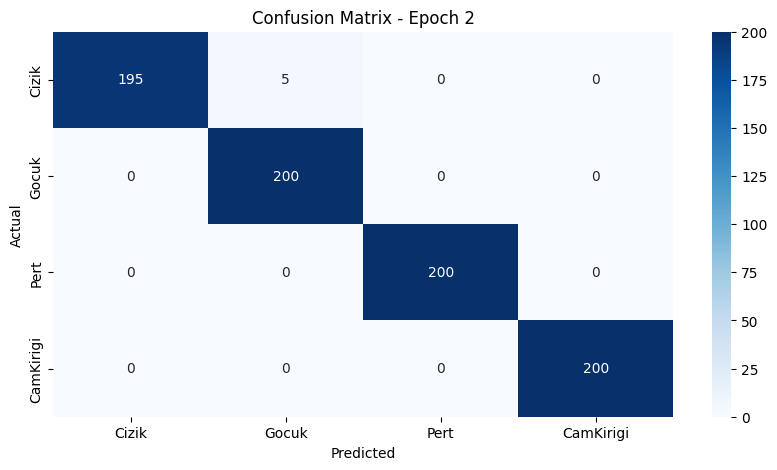

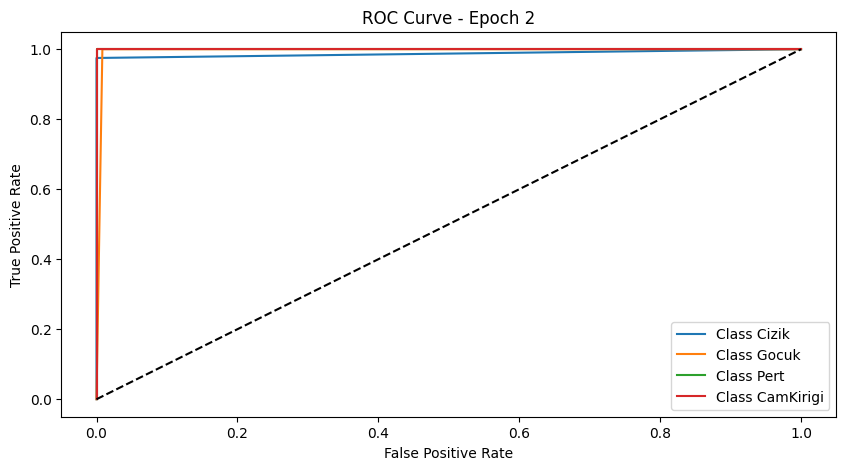

Epoch [3/10]
Accuracy: 0.9950, Recall: 0.9950, Precision: 0.9950, F1-Score: 0.9950, AUC: 0.9967
Training Loss: 0.0120, Validation Loss: 0.0167


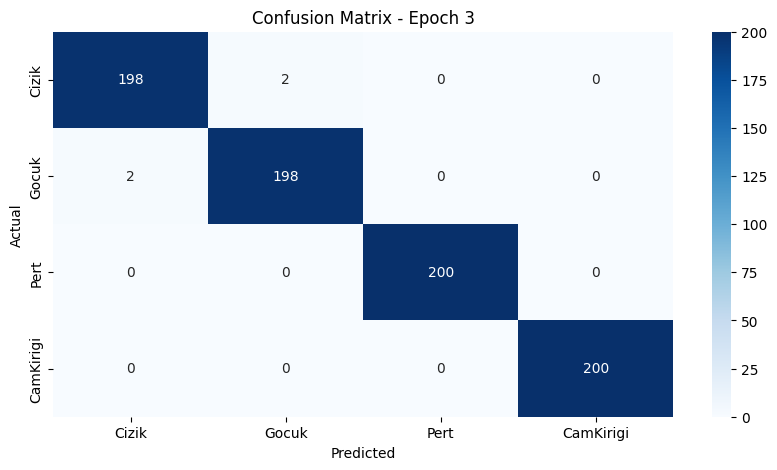

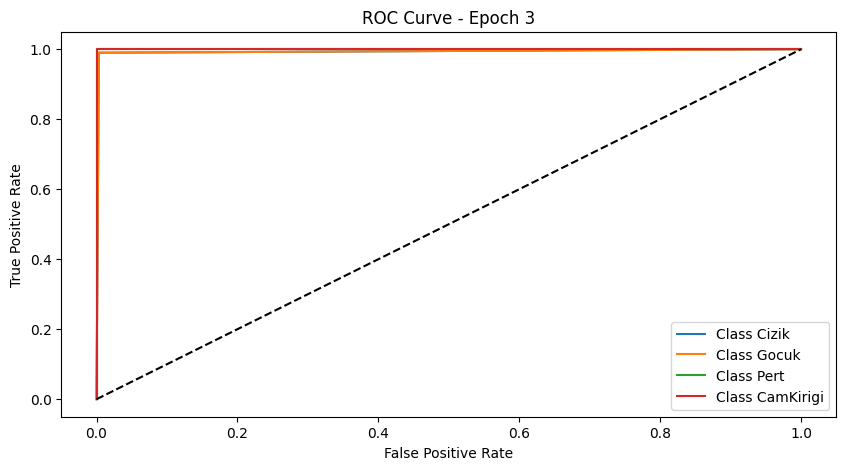

Epoch [4/10]
Accuracy: 0.9912, Recall: 0.9912, Precision: 0.9913, F1-Score: 0.9913, AUC: 0.9942
Training Loss: 0.0059, Validation Loss: 0.0205


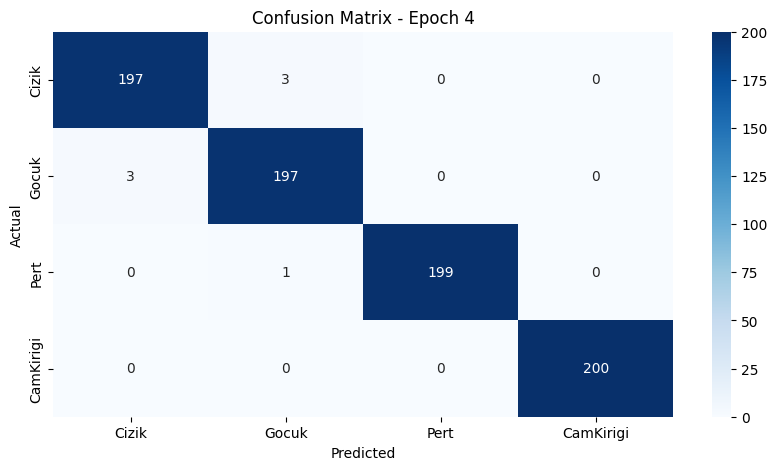

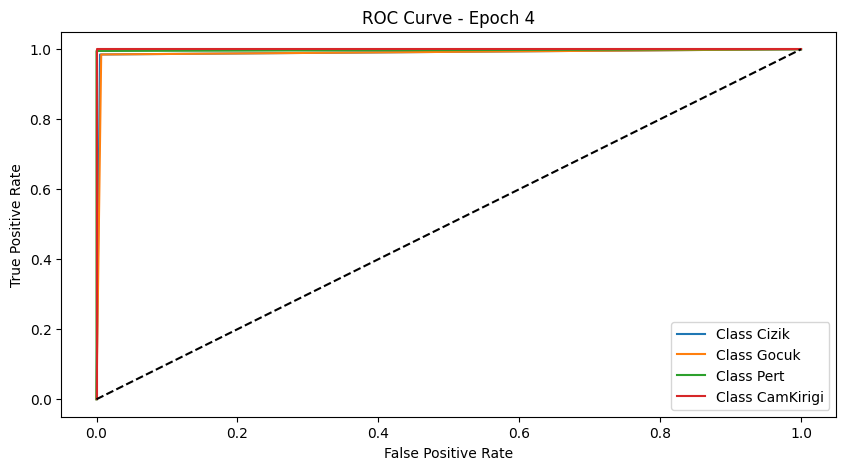

Epoch [5/10]
Accuracy: 0.9938, Recall: 0.9938, Precision: 0.9938, F1-Score: 0.9937, AUC: 0.9958
Training Loss: 0.0021, Validation Loss: 0.0166


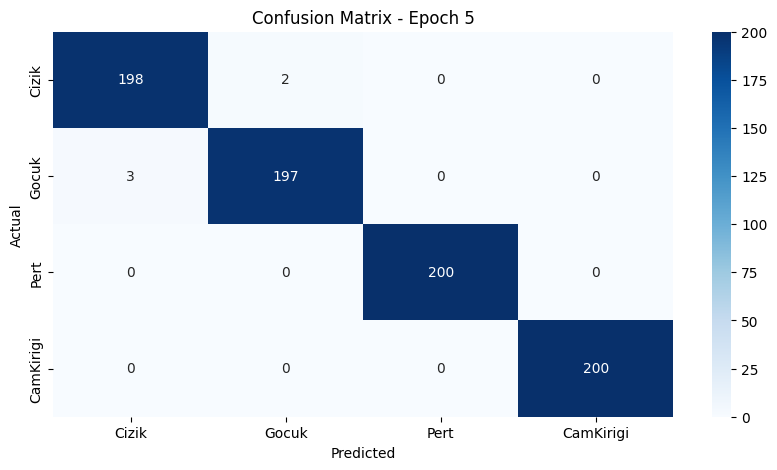

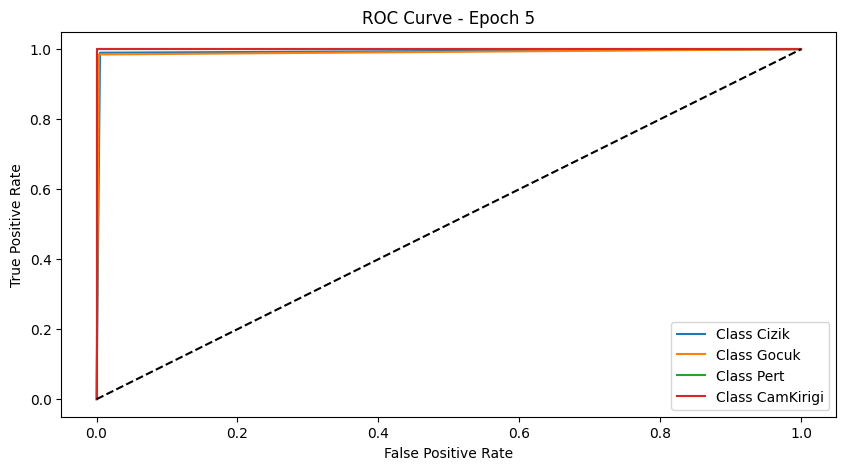

Epoch [6/10]
Accuracy: 0.9925, Recall: 0.9925, Precision: 0.9925, F1-Score: 0.9925, AUC: 0.9950
Training Loss: 0.0011, Validation Loss: 0.0163


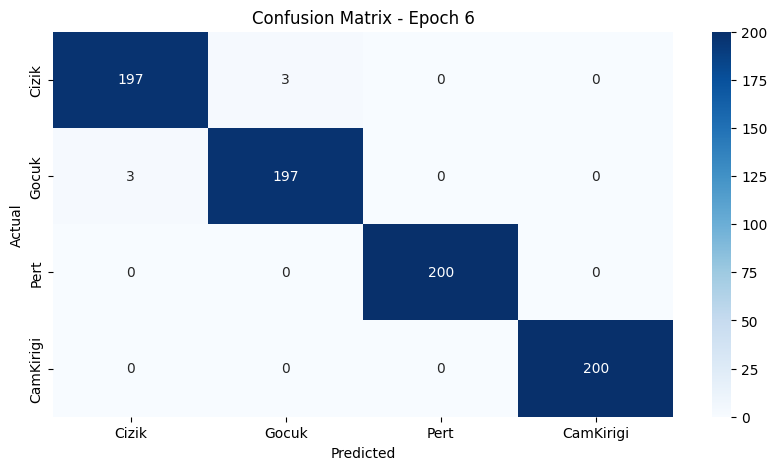

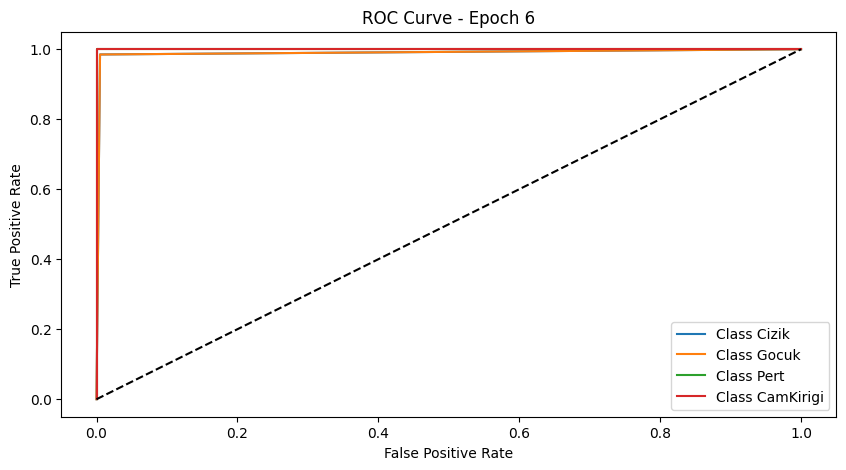

Epoch [7/10]
Accuracy: 0.9925, Recall: 0.9925, Precision: 0.9925, F1-Score: 0.9925, AUC: 0.9950
Training Loss: 0.0008, Validation Loss: 0.0161


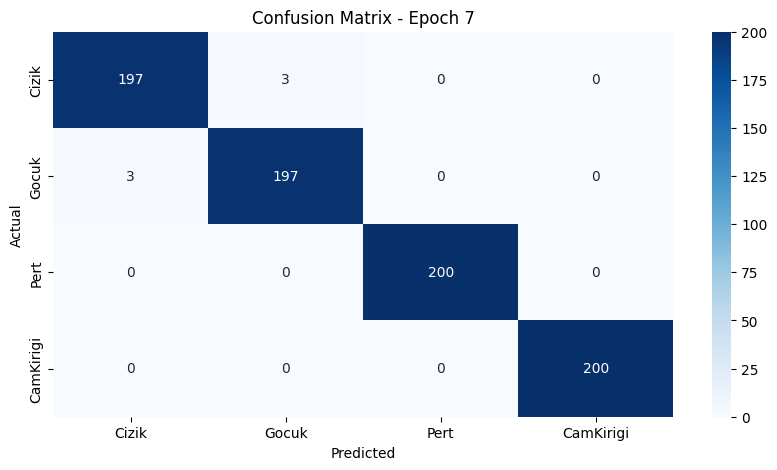

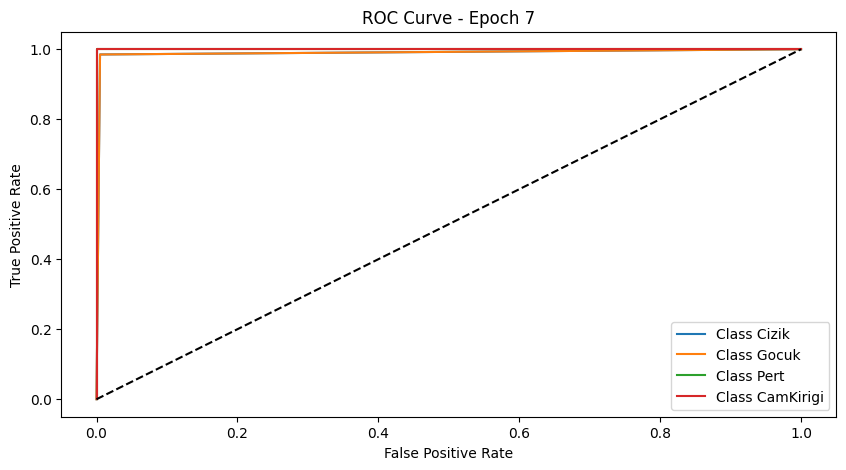

Epoch [8/10]
Accuracy: 0.9938, Recall: 0.9938, Precision: 0.9938, F1-Score: 0.9937, AUC: 0.9958
Training Loss: 0.0007, Validation Loss: 0.0161


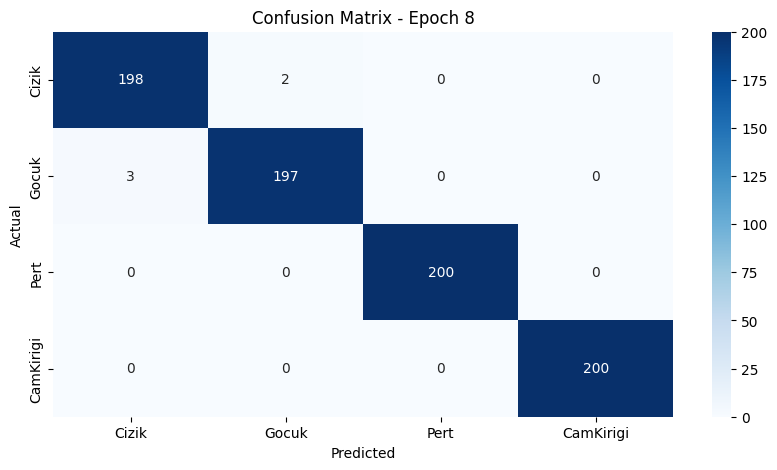

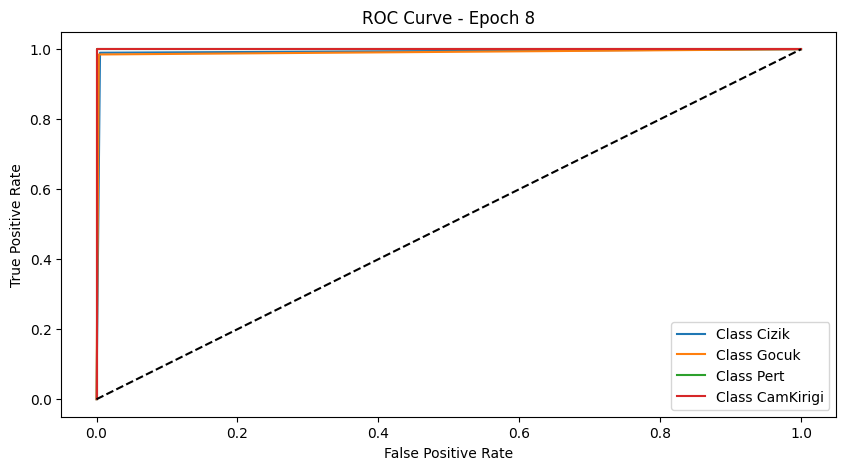

Epoch [9/10]
Accuracy: 0.9938, Recall: 0.9938, Precision: 0.9938, F1-Score: 0.9937, AUC: 0.9958
Training Loss: 0.0005, Validation Loss: 0.0161


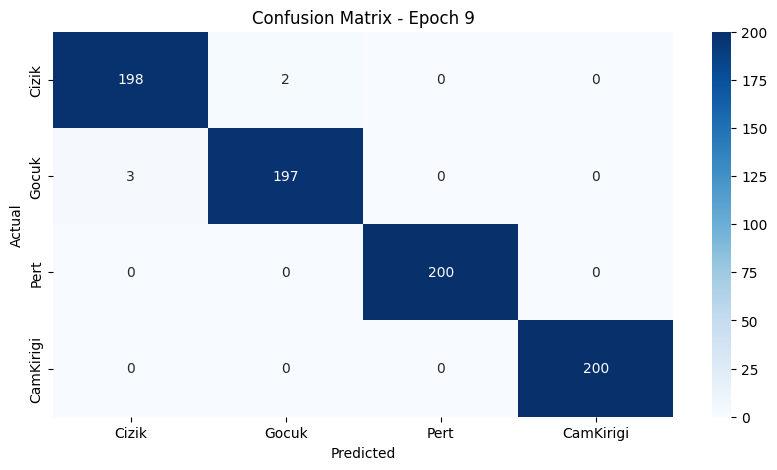

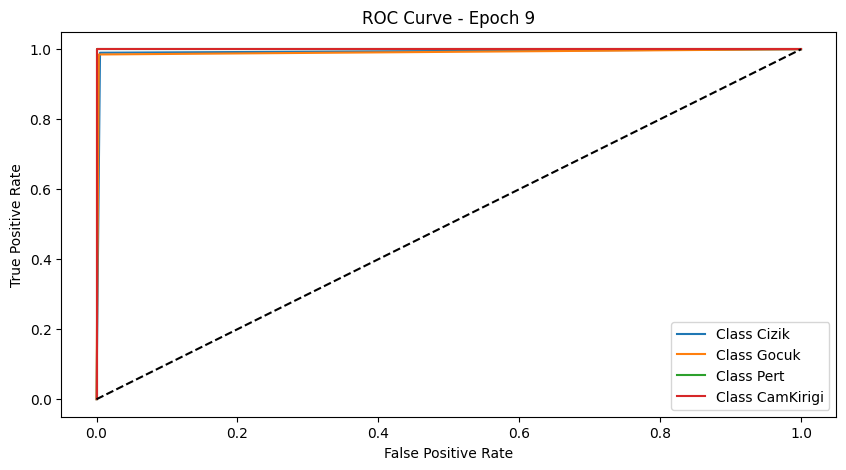

Epoch [10/10]
Accuracy: 0.9938, Recall: 0.9938, Precision: 0.9938, F1-Score: 0.9937, AUC: 0.9958
Training Loss: 0.0005, Validation Loss: 0.0162


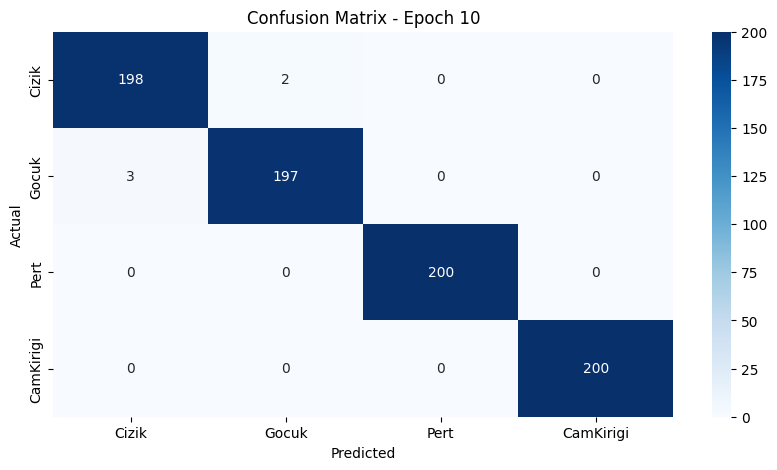

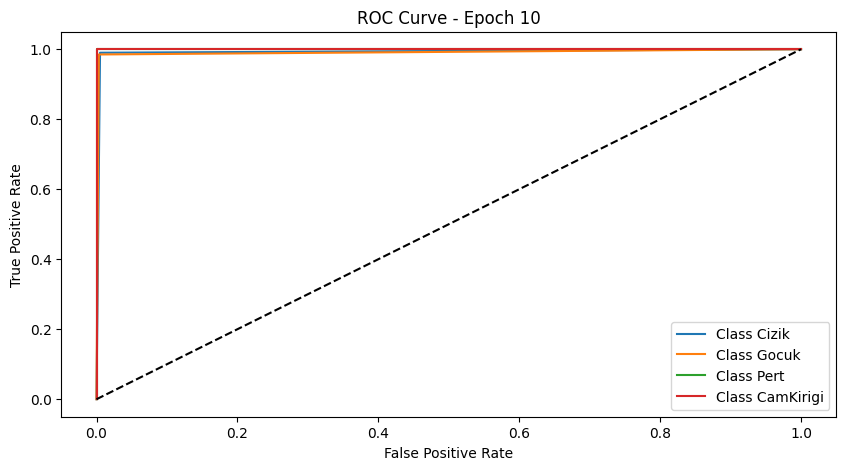

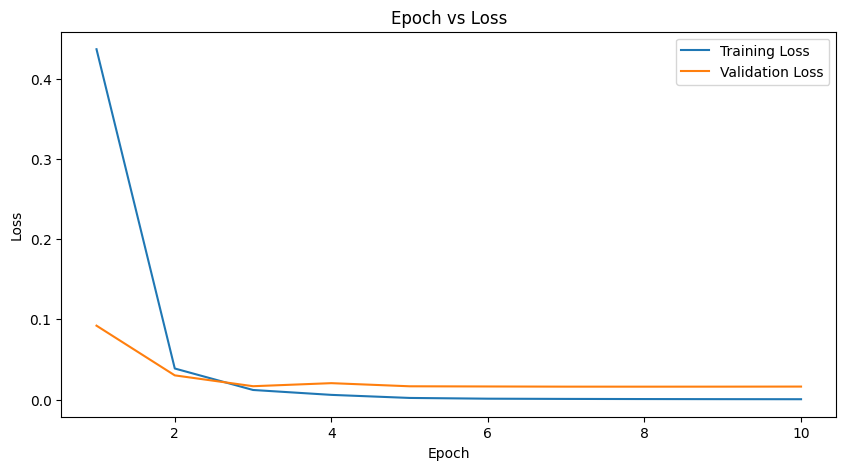

Model başarıyla kaydedildi!


In [17]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from transformers import ConvNextForImageClassification, ConvNextFeatureExtractor
from PIL import Image
from sklearn.model_selection import train_test_split

# Veriyi yükle
data_dir = "/content/drive/My Drive/YazLabProjesi/DATABASE"
classes = ["Cizik", "Gocuk", "Pert", "CamKirigi"]

image_paths = []
labels = []
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# Resimleri ve etiketleri hazırlama
for idx, cls in enumerate(classes):
    class_dir = os.path.join(data_dir, cls)
    for img_file in os.listdir(class_dir):
        if any(img_file.lower().endswith(ext) for ext in valid_extensions):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(idx)

train_image_paths, val_image_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Veri ön işleme (Resimleri boyutlandırma ve normalleştirme)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = CustomDataset(train_image_paths, train_labels, transform=transform)
val_dataset = CustomDataset(val_image_paths, val_labels, transform=transform)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Cihazı ayarla (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ConvNext feature extractor ve modelini yükle
feature_extractor = ConvNextFeatureExtractor.from_pretrained("facebook/convnext-base-224")
model = ConvNextForImageClassification.from_pretrained(
    "facebook/convnext-base-224",
    num_labels=len(classes),  # Etiket sayısına göre son katman boyutunu ayarlama
    ignore_mismatched_sizes=True  # Boyut uyuşmazlıklarını yok sayma
)

model.to(device)

# Kayıp fonksiyonu ve optimizasyon
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

# Eğitim ve doğrulama için liste
train_losses = []
val_losses = []
train_times = []
val_times = []

num_epochs = 10
for epoch in range(num_epochs):
    # Eğitim
    model.train()
    train_loss = 0
    start_time = time.time()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_time = time.time() - start_time
    train_times.append(train_time)
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Doğrulama
    model.eval()
    val_loss = 0
    val_preds = []
    val_labels_list = []
    start_time = time.time()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels_list.extend(labels.cpu().numpy())

    val_time = time.time() - start_time
    val_times.append(val_time)
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Performans metrikleri hesaplama
    accuracy = accuracy_score(val_labels_list, val_preds)
    recall = recall_score(val_labels_list, val_preds, average='macro')
    precision = precision_score(val_labels_list, val_preds, average='macro')
    f1 = f1_score(val_labels_list, val_preds, average='macro')
    auc = roc_auc_score(val_labels_list, torch.nn.functional.one_hot(torch.tensor(val_preds), num_classes=len(classes)), multi_class='ovr')
    cm = confusion_matrix(val_labels_list, val_preds)

    # Metrikleri yazdırma
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1-Score: {f1:.4f}, AUC: {auc:.4f}")
    print(f"Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Karmaşıklık Matrisi ve ROC Eğrisi
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - Epoch {epoch+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Eğrisi
    plt.figure(figsize=(10, 5))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(np.array(val_labels_list) == i, np.array(val_preds) == i)
        plt.plot(fpr, tpr, label=f"Class {classes[i]}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Epoch {epoch+1}")
    plt.legend()
    plt.show()

# Loss Grafiği
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.legend()
plt.show()

# Modeli kaydet
torch.save(model.state_dict(), "/content/drive/My Drive/YazLabProjesi/save/ConvNext_final_model.pth")
print("Model başarıyla kaydedildi!")

In [12]:
!pip install timm